In [1]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import os
import glob


# Load the CSV
df = pd.read_csv(os.path.join('experiments', 'experiments_1_107.csv'))
df.head()

,file_name,bridge_angle,dlman,Fr_ini,plates,cubes,logs,Q[dm],batch,H_up,...,H_down_corr,pic_side,pic_top,dh,dh_d0,rel_BW,carpet_length_avg,carpet_length_max,exp_id,volume
0,dried debris,45.0,0.018605,0.55,0.25,0.00,0.75,18.6,1.0,138.0,...,83.0,685,331,49.0,0.382199,NaN,NaN,NaN,1,1.06
1,NaN,45.0,0.018605,0.55,0.25,0.00,0.75,18.6,2.0,153.0,...,82.0,686,332,65.0,0.539267,NaN,NaN,NaN,1,2.12
2,NaN,45.0,0.018605,0.55,0.25,0.00,0.75,18.6,3.0,157.0,...,82.0,687,333,69.0,0.581152,NaN,NaN,NaN,1,3.18
3,NaN,45.0,0.018605,0.55,0.25,0.00,0.75,18.6,4.0,161.0,...,82.0,688,334,73.0,0.623037,0.623037,?,?,1,4.24
4,N3_R_2P_F0.55_h0.9_0P25C75L_0HR_R1_4L_0HW_45Deg,45.0,0.018605,0.55,0.00,0.25,0.75,18.6,0.0,101.0,...,88.0,NaN,NaN,7.0,0.000000,NaN,NaN,NaN,2,0.00


In [ ]:


def find_photo(folder, pic_num):
    # Try both lowercase and uppercase extensions, and both 3 and 4 digit padding
    for ext in ['jpg', 'JPG', 'jpeg', 'JPEG']:
        for padding in [4, 3]:
            pattern = os.path.join(folder, f"*{pic_num:0{padding}d}.{ext}")
            matches = glob.glob(pattern)
            if matches:
                if len(matches) > 1:
                    print(f"Warning: multiple matches found: {matches}, using first.")
                return matches[0]
    
    raise FileNotFoundError(f"No photo found for number {pic_num} in {folder}")

def inspect_row(excel_row_number):
    # Correct for the rows dropped (header row 1 + rows up to 113)
    df_row = excel_row_number - dropped_rows -2 
    row = df.iloc[df_row]
    
    # Read debris columns
    plates = row['plates']
    cubes = row['cubes']
    logs = row['logs']
    print(f"Excel row {excel_row_number} (df index {df_row}) — Plates: {plates}, Cubes: {cubes}, Logs: {logs}")
    
    # Get picture numbers and print column names to verify
    print(row['pic_top'])
    print(row['pic_side'])
    pic_top_num = int(row['pic_top'])
    pic_side_num = int(row['pic_side'])
    print(f"Column names used: pic_top='{df.columns[df.columns.get_loc('pic_top')]}', pic_side='{df.columns[df.columns.get_loc('pic_side')]}'")
    print(f"Picture numbers — Top: {pic_top_num}, Side: {pic_side_num}")
    
    # Find photos dynamically
    top_path = find_photo(os.path.join('photos', '100OLYMP_Top_1303'), pic_top_num)
    side_path = find_photo(os.path.join('photos', '100OLYMP_side_1303'), pic_side_num)
    
    print(f"Loading top image: {top_path}")
    print(f"Loading side image: {side_path}")
    
    # Open and display images
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(Image.open(top_path))
    axes[0].set_title(f'Top View (pic {pic_top_num})')
    axes[0].axis('off')
    
    axes[1].imshow(Image.open(side_path))
    axes[1].set_title(f'Side View (pic {pic_side_num})')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

inspect_row(38)


Experiment 1 — 3 photo rows
Condition: dried debris
Bridge angle: 45.0 — Froude Number: 0.55
DataFrame indices: [0, 1, 2, 3]


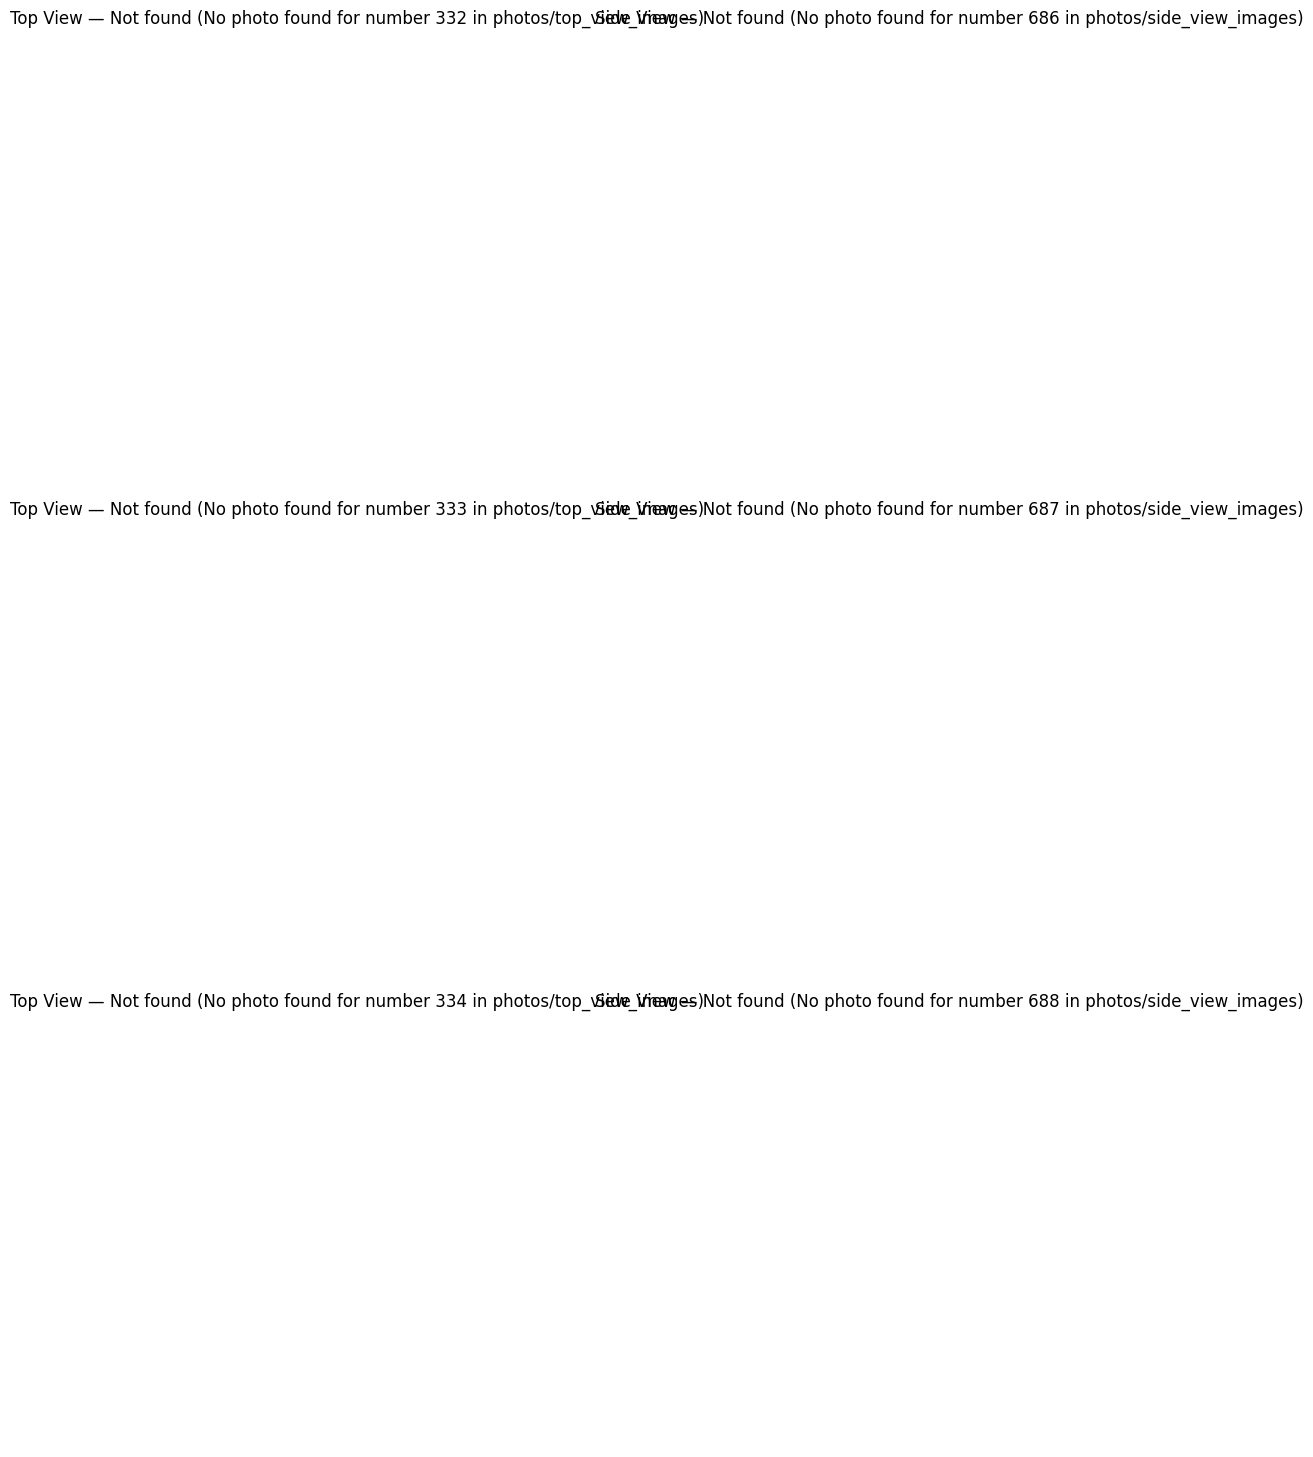

In [3]:
inspect_experiment(1)